# Phase 2: Predicting negative customer reviews

**Our research question:** Can we predict whether a delivered order will receive a negative review (1–2 stars)?

**Our stakeholder:** We focus on the customer experience and seller quality teams, who could use predicted risk to prioritise follow-up after delivery and before a review is submitted.

**Our target:** We define `is_negative_review = 1` for a 1–2 star review and `0` for a 3–5 star review.

**Our selected features:** We use 21 order-level predictors, grouped by the information they represent:

| Feature group [column names] | Why we include them |
|---|---|
| Delivery performance [`delivery_days`, `days_early`, `late_delivery_flag`] | We investigate whether delivery duration and arrival relative to the promised date are associated with dissatisfaction. Negative `days_early` means late; zero means on time; positive means early. |
| Order value and payment [`order_item_value`, `order_freight_value`, `payment_total`, `payment_count`, `max_installments`, `freight_share`] | We examine whether order cost, shipping cost and payment characteristics help explain review risk. |
| Order and seller complexity [`item_count`, `seller_count`, `n_seller_states`] | We test whether orders involving more items or sellers have different review outcomes. |
| Product characteristics [`primary_product_category`, `product_weight_g_mean`, `product_volume_cm3_mean`, `product_photos_qty_mean`] | We examine whether the product mix and physical product characteristics contribute predictive information. |
| Geography [`customer_state`, `seller_state`, `same_state`] | We account for broad customer and seller location differences. |
| Purchase timing [`purchase_month`, `purchase_weekday`] | We allow for seasonal and weekday variation in order experiences. |

These are **candidate predictors**, not proven causes of negative reviews. In our modelling, we evaluate whether they help predict the target rather than assuming every feature is important.

**Our approach:** We compare Logistic Regression, Decision Tree and Random Forest, beginning with simple baselines. We use chronological train/test splitting, cross-validation and hyperparameter tuning, then evaluate the models before choosing one.

**Our prediction point:** We predict immediately after delivery, before a review has been submitted. We therefore exclude orders that were already reviewed before delivery. We do not use review scores, text or timestamps as predictors, because they would reveal information about the outcome.

## 1. We prepare our data and define the target

We build **one row per delivered order** with a known review. We define `is_negative_review = 1` for 1–2 stars and `0` for 3–5 stars.

We use our existing `build_delivered_order_classification_dataset()` function to assemble validated order-level features. Our inputs describe delivery performance, order value, product details and geography.

**Why we filter:** We remove orders whose `review_answer_timestamp` occurred before `order_delivered_customer_date`. Our proposed model predicts at delivery, so it cannot intervene before a review that already exists. We use these two timestamps only for this historical eligibility check, **not** as model features.

In the code below, we print the population before and after filtering so we can explain exactly which orders we model.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import (
    average_precision_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
    make_scorer, ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit, cross_validate, GridSearchCV

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.classification_data import (
    TARGET_COLUMN, DELIVERED_MODEL_FEATURES, build_delivered_order_classification_dataset,
    split_delivered_order_features_target,
)
from src.classification_model import build_delivered_order_logistic_pipeline
from src.classification_tree_model import (
    build_delivered_order_decision_tree_pipeline,
    build_delivered_order_random_forest_pipeline,
)

# We fix the random seed so our results can be reproduced.
SEED = 42

# We load our Phase 1 processed tables.
orders = pd.read_csv(ROOT / "data/processed/order_level.csv")
items = pd.read_csv(ROOT / "data/processed/item_level.csv")

# We reuse the team's validated order-level feature construction.
df = build_delivered_order_classification_dataset(orders, items)

# We align original order timestamps with our modelling rows.
lookup = orders.set_index("order_id").loc[df["order_id"]]
df["purchase_time"] = pd.to_datetime(lookup["order_purchase_timestamp"], format="mixed").to_numpy()

# We identify reviews submitted before delivery.
reviewed_at = pd.to_datetime(lookup["review_answer_timestamp"], format="mixed").to_numpy()
delivered_at = pd.to_datetime(lookup["order_delivered_customer_date"], format="mixed").to_numpy()

# We remove customers who had already reviewed before our prediction point.
already_reviewed = reviewed_at < delivered_at

# We report the original population and our exclusions.
print(f"Delivered orders with review: {len(df):,}")
print(f"Excluded (review before delivery): {already_reviewed.sum():,}")

# We retain eligible orders in chronological order.
df = df.loc[~already_reviewed].sort_values("purchase_time", kind="stable").reset_index(drop=True)
print(f"Eligible orders: {len(df):,}; negative review rate: {df[TARGET_COLUMN].mean():.1%}")

display(df[TARGET_COLUMN].value_counts().rename(index={0:"3–5 stars",1:"1–2 stars"}).to_frame("orders"))

Delivered orders with review: 95,824
Excluded (review before delivery): 4,653
Eligible orders: 91,171; negative review rate: 9.5%


,orders
is_negative_review,
3–5 stars,82542
1–2 stars,8629


## 2. We check leakage and split chronologically

We make predictions **after delivery, before review submission**. That lets us use delivery outcomes such as `days_early` and `late_delivery_flag`, but not information from the review itself. We use `split_delivered_order_features_target()` to keep the feature contract explicit.

**Our feature availability check:** We use `order_delivered_customer_date` to establish the delivery event and derive delivery performance; we do not feed the raw timestamp to the model. This is valid **only because our prediction point is after delivery**. If we were predicting at checkout, `delivery_days`, `days_early` and `late_delivery_flag` would leak future outcomes. We do not use `review_score`, `review_creation_date` or `review_answer_timestamp` as predictors. We derive the target from `review_score` and use `review_answer_timestamp` only to exclude orders that had already reviewed before delivery.

**Our temporal limitation:** We split by purchase time, while our prediction point occurs at delivery. This prevents a random mixture of earlier and later purchases, but does not guarantee that every training order's label was observable before later orders were scored. We acknowledge this limitation instead of claiming that the split eliminates all temporal leakage.

We sort orders by `purchase_time` and reserve the newest 20% for our final test. We train and tune on the earlier 80%. This is a chronological proxy, not a complete simulation of every production event time.

We keep imputation, scaling and categorical encoding inside the scikit-learn pipelines. This matters because preprocessing statistics must be learnt from each training fold, not from future data.

In [2]:
# We select the approved predictors and keep the review label separate.
X, y = split_delivered_order_features_target(df)
assert X.columns.tolist() == DELIVERED_MODEL_FEATURES
assert not any("review" in col for col in X.columns)

# We reserve the newest 20% as our untouched test period.
cut = int(len(df) * 0.80)
X_train, X_test = X.iloc[:cut], X.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

# We quantify imbalance in the eligible modelling population.
negative_rate = y.mean()
majority_accuracy = max(negative_rate, 1 - negative_rate)
print(f"Eligible negative-review rate: {negative_rate:.1%}")
print(f"Majority-class accuracy reference: {majority_accuracy:.1%}")
print("This reference predicts only the most common class and misses the minority class.")

# We show sample sizes and negative-review rates for each period.
display(pd.DataFrame([
    {"population": "Train", "orders": len(y_train), "negative_rate": y_train.mean(),
     "first_purchase": df["purchase_time"].iloc[0].date(),
     "last_purchase": df["purchase_time"].iloc[cut-1].date()},
    {"population": "Test", "orders": len(y_test), "negative_rate": y_test.mean(),
     "first_purchase": df["purchase_time"].iloc[cut].date(),
     "last_purchase": df["purchase_time"].iloc[-1].date()},
]).round(3))

Eligible negative-review rate: 9.5%
Majority-class accuracy reference: 90.5%
This reference predicts only the most common class and misses the minority class.


,population,orders,negative_rate,first_purchase,last_purchase
0,Train,72936,0.097,2016-10-03,2018-05-31
1,Test,18235,0.085,2018-05-31,2018-08-29


## 3. We compare simple baselines using cross-validation

We begin with plain Logistic Regression as an **interpretable linear baseline** and a single Decision Tree as the **simplest tree-based baseline**. We then compare a default Random Forest to test whether combining many trees improves on one tree. These represent **two model families**, consistent with our IT5006 model-family budget. We use the same feature set and evaluation folds for a fair comparison.

We use `TimeSeriesSplit(n_splits=5)` **within the training period**. The validation folds always follow their corresponding training folds in time.

### Why we use these evaluation metrics

Our target is imbalanced: relatively few delivered orders receive a 1–2 star review. We report the rate for the **eligible modelling population**, not just the unfiltered delivered orders. The following code displays that rate and a majority-class accuracy reference so we can see why accuracy alone would be misleading. We therefore do not use overall accuracy as our main measure, because a model could appear accurate simply by predicting non-negative reviews for most orders.

| Metric | What we learn from it | How we use it |
|---|---|---|
| **PR AUC** (`average_precision`) | Across possible decision thresholds, how well do we rank and retrieve rare negative-review cases while maintaining precision? | **Our primary CV model-selection metric.** |
| **Precision** (`precision`) | Of the orders we flag as at risk, what proportion actually receive a negative review? | We assess unnecessary customer follow-ups. |
| **Recall** (`recall`) | Of the orders that receive a negative review, what proportion do we flag? | We assess how many dissatisfied customers we miss. |
| **F1** (`f1`) | How well do we balance precision and recall at a single threshold? | We report one complementary threshold-based summary. |
| **ROC AUC** (`roc_auc`) | How well do we rank a randomly chosen negative-review order above a non-negative one? | We check overall discrimination, while recognising it can look favourable with imbalanced data. |

We choose **PR AUC** because our main challenge is finding a relatively rare negative class and we have not fixed an operational contact threshold. In scikit-learn, we calculate this using **average precision** (`average_precision`), which summarises the precision–recall curve; it is not exactly the same as trapezoidal PR curve area.

We report precision, recall and F1 at the **illustrative 0.50 classification threshold**. Changing that threshold would change these three values, but not PR AUC or ROC AUC.

Our aim is to test whether added model complexity improves meaningful predictive performance, not to maximise the number of metrics or algorithms.

**Checking for overfitting:** we also record each model's score on the training folds it learned from, so we can compare training, validation and test performance in section 5.1.

**Undefined precision:** When a model predicts no negative reviews in a validation fold, precision has no positive predictions to evaluate. We explicitly use `make_scorer(precision_score, zero_division=0)` to report zero rather than repeatedly printing warnings. This changes neither fitted predictions nor our PR AUC model-selection criterion.

In [3]:
# We perform time-ordered validation only on earlier training orders.
cv = TimeSeriesSplit(n_splits=5)

# We evaluate ranking and threshold-based performance.
metrics = {"precision":make_scorer(precision_score, zero_division=0),"recall":"recall","f1":"f1","roc_auc":"roc_auc","pr_auc":"average_precision"}

# We start with simple representatives from the two model families.
baseline = {
    "Logistic (plain)": build_delivered_order_logistic_pipeline(random_state=SEED).set_params(classifier__C=np.inf),
    "Decision Tree (plain)": build_delivered_order_decision_tree_pipeline(random_state=SEED),
    "Random Forest (default)": build_delivered_order_random_forest_pipeline(random_state=SEED, n_estimators=200),
}

# We compare the simple models using the same time-ordered folds.
# We also keep training-fold scores (to check overfitting) and the fold-to-fold spread (for model selection).
rows = []
for name, pipeline in baseline.items():
    result = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=metrics, n_jobs=1, return_train_score=True)
    rows.append({"model":name, **{metric:result[f"test_{metric}"].mean() for metric in metrics},
                 "pr_auc_std":result["test_pr_auc"].std(), "train_pr_auc":result["train_pr_auc"].mean()})
baseline_cv = pd.DataFrame(rows).set_index("model")

display(baseline_cv[list(metrics)].round(3))

,precision,recall,f1,roc_auc,pr_auc
model,,,,,
Logistic (plain),0.489,0.028,0.053,0.645,0.205
Decision Tree (plain),0.144,0.160,0.151,0.528,0.105
Random Forest (default),0.504,0.011,0.022,0.652,0.203


## 4. We tune our two main models

We tune only the two model families we plan to compare: Logistic Regression and Random Forest.

We use small, explainable parameter grids:

| Model | Parameter | Values tested | Why we vary it |
|---|---|---|---|
| Logistic Regression | `classifier__C` | `0.01, 0.1, 1, 10` | We test stronger versus weaker regularisation to control coefficient complexity. |
| Logistic Regression | `classifier__class_weight` | `None, balanced` | We test whether giving more weight to negative reviews improves performance. |
| Random Forest | `classifier__max_depth` | `12, None` | We compare constrained trees with unrestricted depth. |
| Random Forest | `classifier__min_samples_leaf` | `10, 25` | We limit how few training orders can form a leaf, reducing reliance on very small groups. |
| Random Forest | `classifier__class_weight` | `None, balanced_subsample` | We test whether weighting minority cases within each tree's bootstrap sample helps. |

We deliberately test **8 Logistic Regression combinations** and **8 Random Forest combinations**, each across five chronological CV folds. These are limited illustrative grids, not proven optimal ranges. We can explain every parameter without adding more algorithms.

**How we handle imbalance:** We include both `class_weight=None` and class-weighted alternatives in our training-only search. Weighting gives more influence to the minority class during fitting. We do not assume weighting is better: we compare the cross-validation scores and report which setting was selected for each model. We do not add oversampling or SMOTE without evidence that it would improve our approach.

We use `GridSearchCV` with `refit="pr_auc"`, so the best settings are chosen from **training cross-validation PR AUC**. We do not use the held-out test set to choose parameters or select our model. We print the best settings and a concise comparison table.

### How we choose between models

The project brief asks that any more complex model **demonstrate improvement** over a simpler one. We apply this with the **one-standard-error rule** (Hastie, Tibshirani & Friedman, 2009, *The Elements of Statistical Learning*, section 7.10). We find the model with the highest CV PR AUC and calculate the standard error of its score (the standard deviation across the five folds divided by √5). We then choose the **simplest** model whose CV PR AUC lies within one standard error of the best. A smaller difference is within the noise of our cross-validation estimate, so it does not justify a more complex model.

We rank complexity by family: Logistic Regression is the simplest, then a single Decision Tree, then Random Forest. If two candidates are equally simple, we take the one with the higher CV PR AUC. This rule uses training cross-validation results only.

In [4]:
# We tune only on training folds, using PR AUC to select settings.
logistic_grid = GridSearchCV(
    build_delivered_order_logistic_pipeline(random_state=SEED),
    {"classifier__C":[0.01,0.1,1.0,10.0],
     "classifier__class_weight":[None,"balanced"]},
    cv=cv, scoring=metrics, refit="pr_auc", n_jobs=1, return_train_score=True,
)

# We search a compact set of Random Forest settings.
forest_grid = GridSearchCV(
    build_delivered_order_random_forest_pipeline(random_state=SEED,n_estimators=200),
    {"classifier__max_depth":[12,None],
     "classifier__min_samples_leaf":[10,25],
     "classifier__class_weight":[None,"balanced_subsample"]},
    cv=cv, scoring=metrics, refit="pr_auc", n_jobs=1, return_train_score=True,
)

# We fit both searches using training orders only.
logistic_grid.fit(X_train,y_train)
forest_grid.fit(X_train,y_train)

# We summarise the selected settings and CV scores.
tuned = {"Logistic (tuned)":logistic_grid, "Random Forest (tuned)":forest_grid}
print("Selected parameters (training CV only):")
for name, search in tuned.items():
    print(name, search.best_params_)
    selected_weight = search.best_params_["classifier__class_weight"]
    weighted_options = pd.DataFrame(search.cv_results_)[
        ["param_classifier__class_weight", "mean_test_pr_auc"]
    ]
    # We compare the best PR AUC available with and without class weighting.
    weighted_options["weight_setting"] = weighted_options[
        "param_classifier__class_weight"
    ].map(lambda value: "None" if pd.isna(value) else str(value))
    comparison = (
        weighted_options.groupby("weight_setting")["mean_test_pr_auc"]
        .max()
        .rename("best_cv_pr_auc")
    )
    print(f"Selected class weight: {selected_weight!r}")
    display(comparison.round(3).to_frame())

tuned_cv = pd.DataFrame([
    {"model":name, **{metric:search.cv_results_[f"mean_test_{metric}"][search.best_index_] for metric in metrics},
     "pr_auc_std":search.cv_results_["std_test_pr_auc"][search.best_index_],
     "train_pr_auc":search.cv_results_["mean_train_pr_auc"][search.best_index_]}
    for name,search in tuned.items()
]).set_index("model")
cv_results = pd.concat([baseline_cv,tuned_cv])

display(cv_results.sort_values("pr_auc",ascending=False)[list(metrics)].round(3))

# We lock our model choice before examining the test results, using the one-standard-error rule.
complexity = {"Logistic (plain)":0, "Logistic (tuned)":0, "Decision Tree (plain)":1,
              "Random Forest (default)":2, "Random Forest (tuned)":2}
best_name = cv_results["pr_auc"].idxmax()
standard_error = cv_results.loc[best_name,"pr_auc_std"] / np.sqrt(cv.get_n_splits())
within_one_se = cv_results.loc[cv_results["pr_auc"] >= cv_results.loc[best_name,"pr_auc"] - standard_error]
chosen_name = (within_one_se.assign(complexity=within_one_se.index.map(complexity))
               .sort_values(["complexity","pr_auc"], ascending=[True,False]).index[0])
print(f"Highest CV PR AUC: {best_name} ({cv_results.loc[best_name,'pr_auc']:.4f}; one standard error = {standard_error:.4f})")
print("Models within one standard error of the best:", ", ".join(within_one_se.index))
print("Selected model (simplest within one standard error):", chosen_name)

Selected parameters (training CV only):
Logistic (tuned) {'classifier__C': 0.01, 'classifier__class_weight': None}
Selected class weight: None


,best_cv_pr_auc
weight_setting,
None,0.218
balanced,0.217


Random Forest (tuned) {'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__min_samples_leaf': 25}
Selected class weight: None


,best_cv_pr_auc
weight_setting,
None,0.229
balanced_subsample,0.226


,precision,recall,f1,roc_auc,pr_auc
model,,,,,
Random Forest (tuned),0.200,0.000,0.000,0.671,0.229
Logistic (tuned),0.518,0.022,0.042,0.662,0.218
Logistic (plain),0.489,0.028,0.053,0.645,0.205
Random Forest (default),0.504,0.011,0.022,0.652,0.203
Decision Tree (plain),0.144,0.160,0.151,0.528,0.105


Highest CV PR AUC: Random Forest (tuned) (0.2287; one standard error = 0.0201)
Models within one standard error of the best: Logistic (tuned), Random Forest (tuned)
Selected model (simplest within one standard error): Logistic (tuned)


## 5. We evaluate on later orders

We evaluate all models on our held-out test set using PR AUC, ROC AUC, precision, recall and F1. We compare the two tuned finalists using ROC and precision–recall curves.

On our recorded held-out run, the tuned finalists performed almost identically on ranking: **PR AUC 0.187 for Logistic Regression versus 0.188 for Random Forest**, and **ROC AUC 0.649 versus 0.645**, respectively. The PR AUC difference is only `0.001`, so we do not see a compelling ranking advantage from the more complex forest. Both models perform above the test negative-review prevalence reference of approximately **0.085**.

We also observed very low recall at the default `0.50` cutoff: **0.023** for tuned Logistic Regression and approximately **0.001** for tuned Random Forest. This means neither model's default binary classifications are ready for a customer-contact decision, even if its risk ranking is useful. These are **observed test results**, not targets that we tuned toward.

,precision,recall,f1,roc_auc,pr_auc
model,,,,,
Logistic (plain),0.393,0.029,0.053,0.642,0.180
Decision Tree (plain),0.142,0.165,0.153,0.537,0.094
Random Forest (default),0.384,0.025,0.046,0.638,0.178
Logistic (tuned),0.389,0.023,0.043,0.649,0.187
Random Forest (tuned),0.500,0.001,0.001,0.645,0.188


Test prevalence, the random ranking PR reference: 0.085
Model selected before opening the test set: Logistic (tuned)


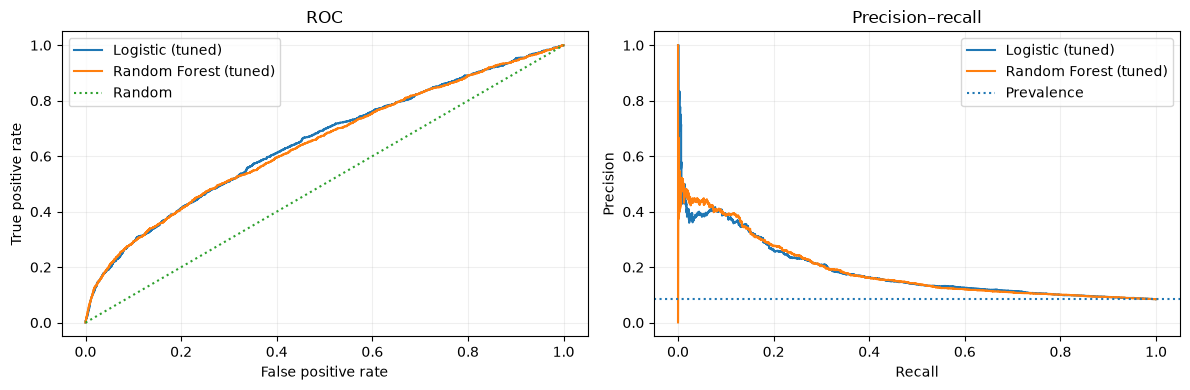

In [5]:
# We train each baseline on earlier orders and keep the test set for evaluation.
fitted = {name:clone(model).fit(X_train,y_train) for name,model in baseline.items()}
fitted.update({name:search.best_estimator_ for name,search in tuned.items()})

# We calculate test probabilities and evaluation metrics.
probs, test_rows = {}, []
for name,model in fitted.items():
    p = model.predict_proba(X_test)[:,1]
    # We use 0.50 solely for the threshold-based classification metrics.
    pred = (p>=0.5).astype(int)
    probs[name] = p
    test_rows.append({
        "model":name, "precision":precision_score(y_test,pred,zero_division=0),
        "recall":recall_score(y_test,pred,zero_division=0),
        "f1":f1_score(y_test,pred,zero_division=0),
        "roc_auc":roc_auc_score(y_test,p), "pr_auc":average_precision_score(y_test,p)
    })
test_results = pd.DataFrame(test_rows).set_index("model")

# We compare results with the prevalence of negative reviews.
display(test_results.round(3))
print(f"Test prevalence, the random ranking PR reference: {y_test.mean():.3f}")
print("Model selected before opening the test set:",chosen_name)

# We plot ranking performance for the tuned finalists.
fig, axes = plt.subplots(1,2,figsize=(12,4))
for name in tuned:
    fpr,tpr,_ = roc_curve(y_test,probs[name])
    precision,recall,_ = precision_recall_curve(y_test,probs[name])
    axes[0].plot(fpr,tpr,label=name)
    axes[1].plot(recall,precision,label=name)

# We add random-ranking references and readable plot labels.
axes[0].plot([0,1],[0,1],linestyle=":",label="Random")
axes[1].axhline(y_test.mean(),linestyle=":",label="Prevalence")
axes[0].set(title="ROC",xlabel="False positive rate",ylabel="True positive rate")
axes[1].set(title="Precision–recall",xlabel="Recall",ylabel="Precision")
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 5.1 We compare training, validation and test performance

We compare each model's PR AUC on the training folds it learned from (**train**), on the later cross-validation folds it did not see (**validation**), and on the held-out later orders (**test**). A model that scores much higher on training data than on validation data is memorising its training orders rather than learning patterns that carry over to new orders. Because our folds follow time, each validation fold covers a different period, so we focus on the size of the train–validation gap rather than on small differences.

In [6]:
# We compare training, validation and test PR AUC to check for overfitting.
fit_check = pd.DataFrame({
    "train_pr_auc": cv_results["train_pr_auc"],
    "validation_pr_auc": cv_results["pr_auc"],
    "test_pr_auc": test_results["pr_auc"],
})
fit_check["train_minus_validation"] = fit_check["train_pr_auc"] - fit_check["validation_pr_auc"]
display(fit_check.loc[test_results.index].round(3))

,train_pr_auc,validation_pr_auc,test_pr_auc,train_minus_validation
model,,,,
Logistic (plain),0.201,0.205,0.180,-0.004
Decision Tree (plain),1.000,0.105,0.094,0.895
Random Forest (default),1.000,0.203,0.178,0.797
Logistic (tuned),0.193,0.218,0.187,-0.025
Random Forest (tuned),0.334,0.229,0.188,0.105


**What we found:**

* **Neither Logistic Regression model shows signs of overfitting.** Their training PR AUC (0.201 plain, 0.193 tuned) is close to, or slightly below, their validation PR AUC (0.205 and 0.218). A training score slightly below the validation score is not a problem here: each fold's training data covers different, earlier periods, and PR AUC depends on how common negative reviews are in each period.
* **The single Decision Tree and the default Random Forest memorise their training orders.** Both score a perfect 1.000 on training folds, but only 0.105 and 0.203 on validation.
* **Tuning reduces the forest's overfitting but does not remove it.** The tuned Random Forest scores 0.334 on training folds against 0.229 on validation, a gap of 0.105.
* **Every model scores lower on the later test period than in validation**, for example 0.218 → 0.187 for tuned Logistic Regression. The test period also has fewer negative reviews (8.5%, against 9.7% in training). On test, the two tuned models end up almost identical (0.187 vs 0.188).
* This supports our selection: tuned Logistic Regression generalises as well as the tuned Random Forest, with far less overfitting.

## 6. We interpret what the model relies on

We use `permutation_importance()` on the selected model and report the 10 inputs with the biggest average decrease in `average_precision` when shuffled.

We interpret these values as **how strongly the fitted model depends on an input for prediction**, not proof that an input causes customers to leave low reviews.

We keep this analysis descriptive. We do not revisit hyperparameters based on test-set feature importance.

### What our feature analysis suggests

In our run, the selected tuned Logistic Regression relied most on `item_count` and `seller_count`: shuffling them decreased test PR AUC by `0.0392` and `0.0373`. `delivery_days` followed (`0.0251`). Every other input had a decrease of `0.004` or less, including `late_delivery_flag` (`0.0015`) and `days_early` (`0.0006`).

This suggests that **order complexity and delivery duration are the main predictive signals** for customers who had not yet reviewed at delivery. Lateness carries much less signal here than our Phase 1 analysis suggested. One possible reason is that many late orders were reviewed before delivery and are excluded from this population. We cannot conclude that additional items or sellers *cause* negative reviews. These figures come from three shuffles per input, so very small values should not be over-interpreted.

In [7]:
# We shuffle each input to measure its effect on held-out PR AUC.
importance = permutation_importance(
    fitted[chosen_name], X_test, y_test, scoring="average_precision",
    n_repeats=3, random_state=SEED, n_jobs=1
)

# We rank the inputs by their average impact on PR AUC.
feature_importance = pd.Series(
    importance.importances_mean,index=X_test.columns,name="PR AUC decrease"
).sort_values(ascending=False)
display(feature_importance.head(10).round(4).to_frame())

,PR AUC decrease
item_count,0.0392
seller_count,0.0373
delivery_days,0.0251
customer_state,0.0040
primary_product_category,0.0033
late_delivery_flag,0.0015
n_seller_states,0.0014
max_installments,0.0013
days_early,0.0006
purchase_weekday,0.0004


## 7. We inspect both models' errors

We compare the tuned Logistic Regression and Random Forest confusion matrices at the same illustrative `0.50` threshold, then examine missed negative reviews and false alarms by delivery characteristics.

Both models miss most negative reviews at this cutoff. We report this limitation rather than adjusting the threshold using the held-out test set.

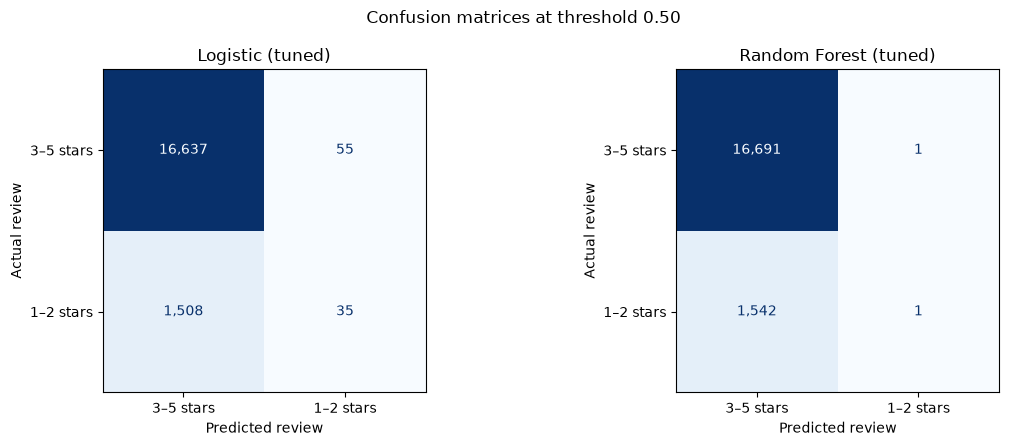

,model,result,orders,late_share,median_delivery_days
0,Logistic (tuned),Correct,16672,0.015,7.0
1,Logistic (tuned),False alarm,55,0.036,9.0
2,Logistic (tuned),Missed negative,1508,0.030,8.0
3,Random Forest (tuned),Correct,16692,0.015,7.0
4,Random Forest (tuned),False alarm,1,0.000,10.0
5,Random Forest (tuned),Missed negative,1542,0.030,8.0


In [8]:
# We compare both tuned models at the same illustrative 0.50 threshold.
finalists = ["Logistic (tuned)", "Random Forest (tuned)"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, name in zip(axes, finalists):
    pred = (probs[name] >= 0.50).astype(int)
    matrix = confusion_matrix(y_test, pred, labels=[0, 1])
    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["3–5 stars", "1–2 stars"],
    ).plot(ax=ax, cmap="Blues", colorbar=False, values_format=",d")
    ax.set_title(name)
    ax.set_xlabel("Predicted review")
    ax.set_ylabel("Actual review")

fig.suptitle("Confusion matrices at threshold 0.50")
plt.tight_layout()
plt.show()

# We compare error patterns for both models.
error_summaries = []
for name in finalists:
    pred = (probs[name] >= 0.50).astype(int)
    errors = X_test.copy()
    errors["actual"] = y_test.to_numpy()
    errors["predicted"] = pred
    errors["result"] = np.select(
        [(errors["actual"] == 1) & (errors["predicted"] == 0),
         (errors["actual"] == 0) & (errors["predicted"] == 1)],
        ["Missed negative", "False alarm"], default="Correct",
    )
    summary = errors.groupby("result").agg(
        orders=("actual", "size"),
        late_share=("late_delivery_flag", "mean"),
        median_delivery_days=("delivery_days", "median"),
    ).reset_index()
    summary.insert(0, "model", name)
    error_summaries.append(summary)

display(pd.concat(error_summaries, ignore_index=True).round(3))

## 8. We select an intervention threshold without looking at the test labels

A probability cutoff of 0.50 is not necessarily appropriate for an imbalanced target. We evaluate both tuned models using **out-of-fold probabilities from five forward-chaining training folds**, never from the held-out test period. Each fold refits the complete pipeline on earlier orders and predicts only its later validation fold. The earliest training observations have no out-of-fold prediction and are excluded from threshold selection.

Our illustrative operational policy is to **maximise recall subject to at least 20% precision** on pooled out-of-fold predictions. This is a stated scenario, not a stakeholder-approved cost threshold. If no threshold meets that precision floor, we explicitly fall back to the threshold with highest out-of-fold F1 and flag that the policy is infeasible. Thresholds are chosen separately for each tuned model. We also show how the trade-off changes across cutoffs; we do not tune thresholds on the held-out test set.

Pooling forward-chaining validation folds can still be affected by time drift and overlapping training histories. These estimates are development diagnostics, not an unbiased final evaluation. A deployment decision would require stakeholder cost assumptions and monitoring.

,threshold,policy_feasible
Logistic (tuned),0.12,True
Random Forest (tuned),0.12,True


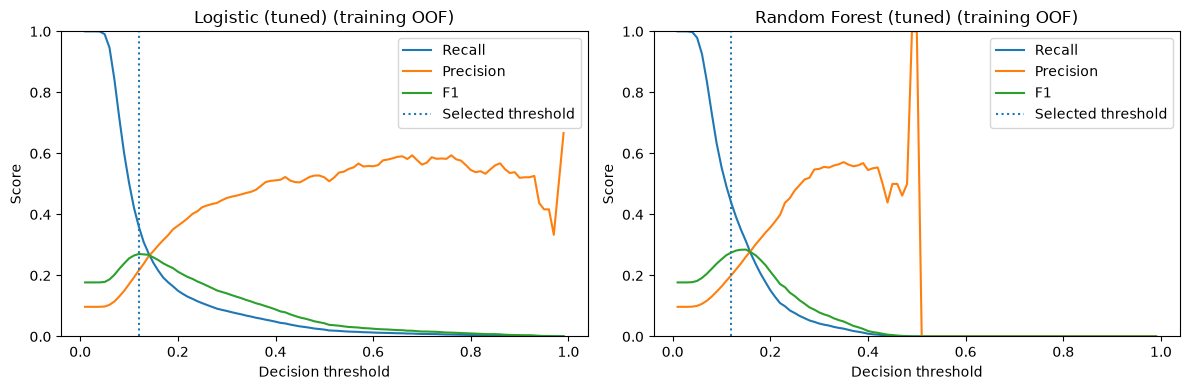

In [9]:
# Generate leakage-safe forward-chaining out-of-fold probabilities on training orders only.
threshold_finalists = ["Logistic (tuned)", "Random Forest (tuned)"]
threshold_candidates = np.unique(np.r_[np.linspace(0.01, 0.99, 99), 0.50])
precision_floor = 0.20  # Illustrative operating constraint, not a stakeholder requirement.
threshold_rows, threshold_choices, oof_predictions = [], {}, {}

for name in threshold_finalists:
    model = fitted[name]
    fold_predictions = pd.Series(np.nan, index=y_train.index, dtype=float)
    for fit_idx, valid_idx in cv.split(X_train):
        fold_model = clone(model)
        fold_model.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        fold_predictions.iloc[valid_idx] = fold_model.predict_proba(X_train.iloc[valid_idx])[:, 1]
    observed = fold_predictions.notna()
    y_oof = y_train.loc[observed].to_numpy()
    p_oof = fold_predictions.loc[observed].to_numpy()
    oof_predictions[name] = fold_predictions
    assert len(y_oof) and len(np.unique(y_oof)) == 2, "OOF validation must include both classes."
    for cutoff in threshold_candidates:
        labels = (p_oof >= cutoff).astype(int)
        threshold_rows.append({
            "model": name, "threshold": float(cutoff),
            "precision": precision_score(y_oof, labels, zero_division=0),
            "recall": recall_score(y_oof, labels, zero_division=0),
            "f1": f1_score(y_oof, labels, zero_division=0),
            "flagged_share": float(labels.mean()),
            "false_alarms": int(((labels == 1) & (y_oof == 0)).sum()),
        })
    options = pd.DataFrame([r for r in threshold_rows if r["model"] == name])
    eligible = options.loc[options["precision"] >= precision_floor]
    feasible = not eligible.empty
    ranking = (eligible.sort_values(["recall", "precision", "threshold"],
                                    ascending=[False, False, False]) if feasible
               else options.sort_values(["f1", "precision", "threshold"],
                                        ascending=[False, False, False]))
    threshold_choices[name] = {"threshold": float(ranking.iloc[0]["threshold"]),
                               "policy_feasible": feasible}

threshold_analysis = pd.DataFrame(threshold_rows)
display(pd.DataFrame(threshold_choices).T)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, threshold_finalists):
    rows = threshold_analysis.loc[threshold_analysis["model"] == name]
    ax.plot(rows["threshold"], rows["recall"], label="Recall")
    ax.plot(rows["threshold"], rows["precision"], label="Precision")
    ax.plot(rows["threshold"], rows["f1"], label="F1")
    ax.axvline(threshold_choices[name]["threshold"], linestyle=":", label="Selected threshold")
    ax.set(title=name + " (training OOF)", xlabel="Decision threshold", ylabel="Score", ylim=(0, 1))
    ax.legend()
plt.tight_layout()
plt.show()

## 9. We evaluate the frozen thresholds once on the held-out period

We apply each threshold selected from training out-of-fold predictions to the existing held-out probabilities. We report precision, recall, F1, predicted-positive share, false alarms and missed negative reviews alongside the 0.50 baseline. **ROC-AUC and PR-AUC do not change when we change only the decision threshold.** This comparison measures the practical trade-off, not a new model fit.

In [10]:
# Evaluate each training-selected threshold once on the untouched chronological test period.
threshold_test_rows = []
for name in threshold_finalists:
    for policy, cutoff in [("Default 0.50", 0.50),
                           ("Training OOF selected", threshold_choices[name]["threshold"])]:
        pred = (probs[name] >= cutoff).astype(int)
        cm = confusion_matrix(y_test, pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        threshold_test_rows.append({
            "model": name, "policy": policy, "threshold": cutoff,
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred, zero_division=0),
            "f1": f1_score(y_test, pred, zero_division=0),
            "flagged_share": float(pred.mean()), "false_alarms": int(fp),
            "missed_negative_reviews": int(fn), "detected_negative_reviews": int(tp),
            "pr_auc_unchanged": average_precision_score(y_test, probs[name]),
            "roc_auc_unchanged": roc_auc_score(y_test, probs[name]),
            "policy_feasible_in_training": threshold_choices[name]["policy_feasible"],
        })
threshold_test_comparison = pd.DataFrame(threshold_test_rows)
display(threshold_test_comparison.round(3))
print("Negative review prevalence in held-out period:", round(float(y_test.mean()), 4))
print("Threshold selection used training OOF predictions only; held-out labels were used for evaluation only.")

,model,policy,threshold,precision,recall,f1,flagged_share,false_alarms,missed_negative_reviews,detected_negative_reviews,pr_auc_unchanged,roc_auc_unchanged,policy_feasible_in_training
0,Logistic (tuned),Default 0.50,0.50,0.389,0.023,0.043,0.005,55,1508,35,0.187,0.649,True
1,Logistic (tuned),Training OOF selected,0.12,0.248,0.222,0.234,0.076,1042,1200,343,0.187,0.649,True
2,Random Forest (tuned),Default 0.50,0.50,0.500,0.001,0.001,0.000,1,1542,1,0.188,0.645,True
3,Random Forest (tuned),Training OOF selected,0.12,0.186,0.340,0.241,0.155,2297,1018,525,0.188,0.645,True


Negative review prevalence in held-out period: 0.0846
Threshold selection used training OOF predictions only; held-out labels were used for evaluation only.


## 10. We conclude and explain the limitations

**Our model selection:** Using training cross-validation only, tuned Random Forest had the highest PR AUC (**0.229**), but tuned Logistic Regression (**0.218**) was within one standard error (**0.020**) of it. Following our one-standard-error rule, we **select tuned Logistic Regression**, the simpler model. An earlier version of this notebook selected the highest cross-validation score outright (tuned Random Forest) and then recommended Logistic Regression on practical grounds. Applying the one-standard-error rule makes our selection and our recommendation consistent.

**Our held-out test findings:** The two tuned models performed almost identically on later orders. Tuned Logistic Regression achieved PR AUC **0.187** and ROC AUC **0.649**; tuned Random Forest achieved PR AUC **0.188** and ROC AUC **0.645**. Both are well above the test prevalence reference of **0.085**. The held-out results therefore show no meaningful advantage for the more complex Random Forest.

**Overfitting:** Section 5.1 shows that tuned Logistic Regression does not overfit (training PR AUC **0.193** vs validation **0.218**). The tuned Random Forest still does (**0.334** vs **0.229**), and the default forest and the single tree memorise their training data (training PR AUC **1.000**).

**What tuning achieved:** Our observed test PR AUC increased from **0.180 to 0.187** for Logistic Regression and from **0.178 to 0.188** for Random Forest. These are descriptive held-out comparisons, **not** evidence that tuning will always improve future performance.

**The default 0.50 threshold is not usable for outreach:** At 0.50, tuned Logistic Regression flagged only **0.5%** of test orders and recalled **2.3%** of negative reviews; tuned Random Forest recalled **0.1%**. This reflects where the cut-off sits, not how well the models rank risk.

**Our threshold findings:** We selected a cutoff from training out-of-fold predictions only: maximise recall while keeping at least 20% precision. For tuned Logistic Regression this gave a cutoff of **0.12**. On the held-out period it flagged **7.6%** of orders and detected **343** negative reviews (recall **22.2%**, precision **24.8%**), at the cost of **1,042** false alarms. Tuned Random Forest at its **0.12** cutoff reached recall **34.0%**, but its held-out precision (**18.6%**) fell below the 20% floor. This is an exploratory operating-point analysis, not a stakeholder-approved intervention policy.

**How our stakeholder could use the result:** The customer experience team could rank newly delivered orders that have not already been reviewed, and contact the highest-risk customers first. In our model, orders with more items or sellers and longer delivery times carry the most risk. Predicted risk does not prove that an intervention would prevent a negative review.

**Our class imbalance sensitivity check:** A separate chronological validation experiment compared natural Logistic Regression training with balanced class weights and 50/50 training-only undersampling. Neither balancing approach materially improved PR AUC; see the [classification workflow documentation](../docs/phase2-classification-workflow.md) and [recorded CSV](../reports/phase2/three_approaches.csv). These results do not replace the main cross-validation comparison.

**Our limitations:** We use historical Olist data; some causes of dissatisfaction are not recorded; we exclude the 4,653 orders reviewed before delivery, so the model does not cover those customers; and our purchase-time split is not a complete reproduction of real-world scoring conditions. Our measured differences between the tuned models are small, and permutation importance uses only three shuffles per input.

**Our next step:** Before Phase 3, agree a stakeholder-defined cost or precision–recall trade-off for the selected Logistic Regression, and validate the chosen operating policy prospectively before using scores for customer outreach.

## 11. How our work connects to our Phase 1 literature review

The table shows where each source from our Phase 1 literature review supports a choice or finding in this notebook. Full references follow below.

| Where in this notebook | What the source supports | Reference(s) |
|---|---|---|
| **Introduction:** research question and stakeholder | Negative reviews after delivery matter commercially: ratings affect sales, and missing the promised delivery date has measurable costs. Machine learning is widely used for e-commerce prediction problems. | Deshpande & Pendem (2022); Cui et al. (2023); Zhang et al. (2023) |
| **Introduction:** feature table, *Delivery performance* | Longer delivery lowers ratings, and customers judge delivery against the **promised** date. This is the rationale for `delivery_days`, `days_early` and `late_delivery_flag`. | Deshpande & Pendem (2022); Cui et al. (2023) |
| **Introduction:** feature table, delivery lead time | The promised lead time (expected delivery date minus order date) has been used as a predictor of delivery outcomes. | Kandula et al. (2021) |
| **Introduction:** feature table, *Product characteristics* and *Geography* | Target encoding is the evidence-supported option for very high-cardinality categories. Our categorical inputs have a moderate number of levels (up to 73 product categories), so we use one-hot encoding with regularised models. | Micci-Barreca (2001); Pargent et al. (2022) |
| **Sections 1 and 2:** filtering and the leakage check | Information from after the outcome must not be used as an input, because leakage inflates apparent performance, especially the gains of complex models over simple ones. Our Phase 1 review also noted that random splits of time-ordered data overestimate performance, which is why we split chronologically. | Kapoor & Narayanan (2023); Phase 1 literature review |
| **Section 3:** baseline models | A simple model such as Logistic Regression is an important control for judging whether complex models add value. Tree-based ensembles are the established choice for tabular data. | Kapoor & Narayanan (2023); Grinsztajn et al. (2022) |
| **Section 3:** evaluation design | Five-fold cross-validation for stable performance estimates. | Pargent et al. (2022) |
| **Section 4:** how we handle imbalance | Rebalancing the classes does not improve a model's ranking ability and can distort its risk scores. This matches our result that class weighting was not selected. Cost-sensitive learning (class weighting) is preferable to resampling. | van den Goorbergh et al. (2022); Kandula et al. (2021) |
| **Section 4:** how we choose between models | The one-standard-error rule: choose the simplest model within one standard error of the best cross-validation score. | Hastie et al. (2009) |
| **Sections 5 and 5.1:** evaluation on later orders | Under a strict evaluation, complex models often lose their advantage over simple ones, consistent with tuned Logistic Regression and tuned Random Forest performing almost identically. | Kapoor & Narayanan (2023) |
| **Section 6:** feature importance | The literature and our Phase 1 analysis found that delivery timing drives ratings. In our eligible population, lateness carries little signal, likely because many late orders were reviewed before delivery and are excluded. | Deshpande & Pendem (2022); Cui et al. (2023) |
| **Sections 8 and 9:** threshold selection | Adjusting the decision threshold, rather than resampling the data, is the recommended way to trade sensitivity against precision. The right trade-off depends on business costs, so a stakeholder must set it. | van den Goorbergh et al. (2022); Cui et al. (2023) |
| **Section 10:** conclusion and limitations | Calibration (whether risk scores match observed rates) should be reported alongside ranking quality, and we have not yet done so. Tree ensembles did not outperform Logistic Regression here, unlike the general benchmark finding. A future step is leakage-safe, history-based encoding of high-cardinality inputs such as seller ID. | van den Goorbergh et al. (2022); Grinsztajn et al. (2022); Micci-Barreca (2001); Pargent et al. (2022) |

## References

Cui, R., Sun, T., Lu, Z., & Golden, J. M. (2023). Sooner or later? Promising delivery speed in online retail. *Manufacturing & Service Operations Management*. https://doi.org/10.1287/msom.2021.0174

Deshpande, V., & Pendem, P. (2022). Logistics performance, ratings, and its impact on customer purchasing behavior and sales in e-commerce platforms. *Manufacturing & Service Operations Management, 25*(3), 827–845. https://doi.org/10.1287/msom.2021.1045

Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). Why do tree-based models still outperform deep learning on typical tabular data? *Advances in Neural Information Processing Systems 35*, Datasets and Benchmarks Track. https://doi.org/10.48550/arXiv.2207.08815

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer.

Kandula, S., Krishnamoorthy, S., & Roy, D. (2021). A prescriptive analytics framework for efficient e-commerce order delivery. *Decision Support Systems, 147*, 113584. https://doi.org/10.1016/j.dss.2021.113584

Kapoor, S., & Narayanan, A. (2023). Leakage and the reproducibility crisis in machine-learning-based science. *Patterns, 4*(9), 100804. https://doi.org/10.1016/j.patter.2023.100804

Micci-Barreca, D. (2001). A preprocessing scheme for high-cardinality categorical attributes in classification and prediction problems. *SIGKDD Explorations, 3*(1), 27–32. https://doi.org/10.1145/507533.507538

Pargent, F., Pfisterer, F., Thomas, J., & Bischl, B. (2022). Regularized target encoding outperforms traditional methods in supervised machine learning with high cardinality features. *Computational Statistics, 37*(5), 2671–2692. https://doi.org/10.1007/s00180-022-01207-6

van den Goorbergh, R., van Smeden, M., Timmerman, D., & Van Calster, B. (2022). The harm of class imbalance corrections for risk prediction models: Illustration and simulation using logistic regression. *Journal of the American Medical Informatics Association, 29*(9), 1525–1534. https://doi.org/10.1093/jamia/ocac093

Zhang, X., Guo, F., Chen, T., Pan, L., Beliakov, G., & Wu, J. (2023). A brief survey of machine learning and deep learning techniques for e-commerce research. *Journal of Theoretical and Applied Electronic Commerce Research, 18*(4), 2188–2216. https://doi.org/10.3390/jtaer18040110

Team 01 (2026). *Group project milestone 1: Literature review and exploratory data analysis* [Unpublished course report]. IT5006 Fundamentals of Data Analytics, National University of Singapore.